In [17]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import imgaug as ia
import imgaug.augmenters as iaa
import pickle
ia.seed(1)

In [20]:
seq = iaa.Sequential([
    iaa.Fliplr(0.5), # horizontal flips
    iaa.Crop(percent=(0, 0.1)), # random crops
    # Small gaussian blur with random sigma between 0 and 0.5.
    # But we only blur about 50% of all images.
    iaa.Sometimes(
        0.5,
        iaa.GaussianBlur(sigma=(0, 0.5))
    ),
    # Strengthen or weaken the contrast in each image.
    iaa.LinearContrast((0.75, 1.5)),
    # Add gaussian noise.
    # For 50% of all images, we sample the noise once per pixel.
    # For the other 50% of all images, we sample the noise per pixel AND
    # channel. This can change the color (not only brightness) of the
    # pixels.
    iaa.AdditiveGaussianNoise(loc=0, scale=(0.0, 0.05*255), per_channel=0.5),
    # Make some images brighter and some darker.
    # In 20% of all cases, we sample the multiplier once per channel,
    # which can end up changing the color of the images.
    iaa.Multiply((0.8, 1.2), per_channel=0.2),
    # Apply affine transformations to each image.
    # Scale/zoom them, translate/move them, rotate them and shear them.
    iaa.Affine(
        scale={"x": (0.8, 1.2), "y": (0.8, 1.2)},
        translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)},
        rotate=(-25, 25),
        shear=(-8, 8)
    )
], random_order=True) # apply augmenters in random order

In [25]:
path ="samples"
imgs = os.listdir(path)
labels = [f.strip('.jpg') for f in imgs]

if not os.path.isdir(f'{typ}'):
        os.mkdir(f'{typ}')

In [31]:
N = 100
dim = 227

typ = 'train/'
if not os.path.isdir(f'{typ}'):
        os.mkdir(f'{typ}')
        
for label in labels:
    img = cv2.imread(os.path.join(path,f'{label}.jpg'),0)
    # resize image
    img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
    images = np.array([ img for _ in range(N)],dtype=np.uint8)
    
    images_aug = seq(images=images)

    if not os.path.isdir(f'train/{label}'):
        os.mkdir(f'train/{label}')

    for i in range(N):
        cv2.imwrite(f'train/{label}/{label}_{i}.jpg',images_aug[i])

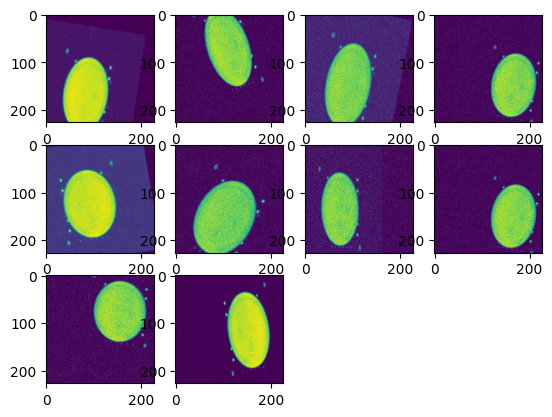

In [33]:
num = 10
col=4
imgs = list(np.random.choice(len(images_aug),num))
for i in range(num):
    plt.subplot(num/col if num%col==0 else int(num/col)+1,col,i+1)
    plt.imshow(images_aug[imgs[i]])